# Notebook 12: Portfolio Analytics Agent (Full Production Pipeline)

## Overview
This notebook is the **Analytics Agent** -- the second agent in a two-agent system.

- **Notebook 11** (Builder) = defines and exports the portfolio
- **Notebook 12** (this one) = reads the portfolio and runs full analysis

## Architecture
```
load_portfolio -> build_benchmark_context -> analyze_holdings
    -> compute_risk -> generate_analysis -> END
```

## What This Agent Does
1. Loads the portfolio from the JSON file exported by Notebook 11
2. Compares sector weights against S&P 500 benchmark
3. Fetches live market data via yfinance (price, technicals, fundamentals)
4. Scores each holding with 17 rule-based scoring rules (BUY/HOLD/SELL)
5. Computes portfolio-level risk metrics (beta, HHI, sector concentration)
6. Generates LLM analysis covering sector exposure, ROI, risk, rebalancing
7. Gets LLM structured signals per holding and combines with rule scores (60/40)

## How to Use This Notebook

### Prerequisites
1. **Notebook 11 is optional**: If you have run Notebook 11 and exported a portfolio (`../data/outputs/portfolio.json`), this notebook will use it. Otherwise, a **sample portfolio** (VTI, QQQ, XLV, AAPL, JNJ, BND, etc.) is loaded automatically so the notebook works standalone.
2. **Environment file**: Create a `.env` file in the project root (`../.env`) with your API keys:
   ```
   LLM_PROVIDER=openai
   LLM_MODEL=gpt-4.1-mini
   OPENAI_API_KEY=your-openai-key
   ```
3. **Install packages**: The first code cell installs all required packages automatically (including `yfinance` for live market data).

### Running the Notebook
1. **Run All Cells** (recommended): Use `Kernel > Restart & Run All` or click **Run All** to execute every cell top to bottom. The notebook will:
   - Install dependencies and load the portfolio (or use the sample)
   - Fetch live market data for each holding via yfinance (~15-30 seconds)
   - Run 17-rule scoring per holding (technical + fundamental)
   - Compute portfolio-level risk metrics (beta, HHI, concentration)
   - Generate a comprehensive LLM analysis report
   - Run 7 demo queries asking specific portfolio questions
2. **Run Cell by Cell**: Execute cells one at a time with `Shift + Enter` to step through the pipeline and inspect each stage.

### Demo Queries (After Pipeline)
After the pipeline runs, the notebook includes 7 pre-built demo queries that ask the LLM about the analysis results:

| Demo | Query | What It Tests |
|------|-------|---------------|
| 1 | "Here are my holdings -- how is my portfolio doing?" | Overall portfolio health summary |
| 2 | "What is my total ROI?" | Return on investment analysis |
| 3 | "Am I too concentrated in healthcare?" | Sector concentration risk |
| 4 | "How volatile is my portfolio?" | Volatility and beta assessment |
| 5 | "Compare my returns to S&P 500." | Benchmark comparison |
| 6 | "Should I rebalance?" | Rebalancing recommendations |
| 7 | "Which ETF is underperforming?" | Underperforming holdings identification |

### Output
The pipeline produces:
- **LLM Analysis Report**: Comprehensive markdown analysis with sector exposure, risk, ROI, and rebalancing recommendations
- **Per-Holding Scores**: 17-rule scoring with combined rule + LLM signals (60/40 weighting)
- **Risk Metrics**: Portfolio beta, HHI concentration, sector breakdown

## Installation

In [21]:
%pip install langchain langchain-openai langgraph python-dotenv pandas pydantic yfinance --quiet

print("Packages installed")


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Packages installed


## Imports

In [22]:
import json
import os
from typing import Annotated, Sequence

import pandas as pd
import numpy as np
import yfinance as yf
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage, SystemMessage
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display, Markdown

from ai_course_utils import load_llm_from_env, display_config

# Load environment
load_dotenv()
load_dotenv('../.env')

print("Imports successful")

Imports successful


## Configuration

In [23]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               Set
  Google               Not set
  Mistral              Not set
  Anthropic            Not set
  Serper (Web Search)  Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Load Portfolio from Notebook 11

This reads the JSON file exported by Notebook 11. If the file does not
exist (e.g. you have not run Notebook 11 yet), a **sample portfolio**
is used so this notebook can run standalone for demonstration purposes.

In [24]:
# ============================================================================
# USER INPUT: Path to portfolio JSON from Notebook 11
# ============================================================================
portfolio_file = "../data/outputs/portfolio.json"

# Sample portfolio used when Notebook 11 has not been run yet
SAMPLE_PORTFOLIO = {
    "name": "Sample Balanced Growth Portfolio",
    "description": "A diversified portfolio for demonstration purposes, "
                   "blending broad market ETFs with sector exposure and bonds.",
    "holdings": [
        {"ticker": "VTI",  "company_name": "Vanguard Total Stock Market ETF",
         "allocation_pct": 25.0, "investment_type": "ETF",
         "rationale": "Broad US equity exposure"},
        {"ticker": "QQQ",  "company_name": "Invesco QQQ Trust",
         "allocation_pct": 15.0, "investment_type": "ETF",
         "rationale": "Growth-oriented tech exposure"},
        {"ticker": "XLV",  "company_name": "Health Care Select Sector SPDR Fund",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Healthcare sector tilt"},
        {"ticker": "VWO",  "company_name": "Vanguard FTSE Emerging Markets ETF",
         "allocation_pct": 10.0, "investment_type": "ETF",
         "rationale": "Emerging market diversification"},
        {"ticker": "XLE",  "company_name": "Energy Select Sector SPDR Fund",
         "allocation_pct": 5.0,  "investment_type": "ETF",
         "rationale": "Energy sector and inflation hedge"},
        {"ticker": "AAPL", "company_name": "Apple Inc.",
         "allocation_pct": 10.0, "investment_type": "Stock",
         "rationale": "Large-cap growth with strong cash flow"},
        {"ticker": "JNJ",  "company_name": "Johnson & Johnson",
         "allocation_pct": 5.0,  "investment_type": "Stock",
         "rationale": "Defensive healthcare with dividend income"},
        {"ticker": "BND",  "company_name": "Vanguard Total Bond Market ETF",
         "allocation_pct": 15.0, "investment_type": "Bond ETF",
         "rationale": "Fixed income for stability and income"},
        {"ticker": "GLD",  "company_name": "SPDR Gold Shares",
         "allocation_pct": 5.0,  "investment_type": "Commodity ETF",
         "rationale": "Inflation hedge and portfolio diversifier"},
    ],
}

if os.path.exists(portfolio_file):
    with open(portfolio_file) as f:
        PORTFOLIO = json.load(f)
    print(f"Portfolio loaded from {portfolio_file}")
else:
    PORTFOLIO = SAMPLE_PORTFOLIO
    print(f"No portfolio file found at {portfolio_file}")
    print("Using SAMPLE portfolio for demonstration\n")

print(f"  Name: {PORTFOLIO['name']}")
print(f"  Holdings: {len(PORTFOLIO['holdings'])}")
print()
for h in PORTFOLIO['holdings']:
    print(f"  {h['ticker']:<6} {h['allocation_pct']:>5.1f}%  {h['company_name']}")

No portfolio file found at ../data/outputs/portfolio.json
Using SAMPLE portfolio for demonstration

  Name: Sample Balanced Growth Portfolio
  Holdings: 9

  VTI     25.0%  Vanguard Total Stock Market ETF
  QQQ     15.0%  Invesco QQQ Trust
  XLV     10.0%  Health Care Select Sector SPDR Fund
  VWO     10.0%  Vanguard FTSE Emerging Markets ETF
  XLE      5.0%  Energy Select Sector SPDR Fund
  AAPL    10.0%  Apple Inc.
  JNJ      5.0%  Johnson & Johnson
  BND     15.0%  Vanguard Total Bond Market ETF
  GLD      5.0%  SPDR Gold Shares


## S&P 500 Sector Benchmark

In [25]:
SP500_SECTOR_WEIGHTS = {
    "Technology": 31.0,
    "Healthcare": 12.0,
    "Financial Services": 13.0,
    "Consumer Cyclical": 10.0,
    "Communication Services": 9.0,
    "Industrials": 8.0,
    "Consumer Defensive": 6.0,
    "Energy": 4.0,
    "Utilities": 3.0,
    "Real Estate": 2.0,
    "Basic Materials": 2.0,
}

print("S&P 500 sector benchmark loaded")

S&P 500 sector benchmark loaded


## Define Analytics State

In [26]:
class AnalyticsState(BaseModel):
    """State that flows through the analytics agent graph."""

    model_config = {"arbitrary_types_allowed": True}

    messages: Annotated[Sequence[BaseMessage], add_messages] = []
    portfolio: dict = {}
    benchmark_context: str = ""
    sector_rows: list[dict] = []
    holdings_analysis: list[dict] = []
    risk_metrics: dict = {}


print("AnalyticsState defined")

AnalyticsState defined


## Analysis Prompt

In [27]:
ANALYSIS_PROMPT = """You are an expert investment analyst evaluating a portfolio. \
You have been provided with:

1. **Sector weight comparison** against the S&P 500 benchmark
2. **Per-holding analysis** with live technical indicators (RSI, MACD, SMA), \
fundamentals (P/E, P/B, ROE, beta), and rule-based BUY/HOLD/SELL scores
3. **Portfolio-level risk metrics** (beta, concentration, sector breakdown)

Produce a comprehensive analysis covering ALL of the following:

## Sector Exposure
- Which sectors are overweight/underweight vs S&P 500
- Concentration risks in specific sectors

## Individual Holdings Review
- Flag holdings with SELL signals or very low scores
- Highlight strong BUY-signal holdings
- Note any overbought (RSI >70) or oversold (RSI <30) positions

## Risk Assessment
- Portfolio beta and volatility exposure
- Concentration risk (single-stock and sector)
- Valuation risk (average P/E vs market)

## ROI & Performance Indicators
- Holdings with strong momentum (MACD bullish, RSI 50-70)
- Dividend income potential
- Growth vs value tilt

## Rebalancing Recommendations
- Specific positions to reduce or increase
- Sector adjustments needed to improve diversification
- Priority actions ranked by urgency

Format in markdown with clear sections. Be specific — use ticker symbols, \
percentages, and scores from the data provided. Keep each section concise."""

print("Analysis prompt defined")

Analysis prompt defined


## Market Data & Technical Indicators

Live data fetching, technical indicator computation, and the
17-rule scoring system.

In [28]:
def _scalar(x):
    """Convert numpy/pandas scalar to plain Python float."""
    try:
        if hasattr(x, "item"):
            return x.item()
        if pd.isna(x):
            return None
        return float(x)
    except (TypeError, ValueError):
        return None


def fetch_price_history(ticker: str, period: str = "1y") -> pd.DataFrame:
    """Fetch OHLCV history from yfinance."""
    try:
        df = yf.download(ticker, period=period, progress=False, auto_adjust=True)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df
    except Exception as e:
        print(f"    yfinance download failed for {ticker}: {e}")
        return pd.DataFrame()


def fetch_fundamentals(ticker: str) -> dict:
    """Fetch fundamental metrics from yfinance."""
    try:
        info = yf.Ticker(ticker).info
        return {
            "company_name": info.get("shortName") or info.get("longName", ticker),
            "sector": info.get("sector", "Unknown"),
            "current_price": info.get("currentPrice") or info.get("regularMarketPrice"),
            "pe_ratio": info.get("trailingPE") or info.get("forwardPE"),
            "pb_ratio": info.get("priceToBook"),
            "roe": info.get("returnOnEquity"),
            "dividend_yield": info.get("dividendYield"),
            "beta": info.get("beta"),
            "market_cap": info.get("marketCap"),
            "52_week_high": info.get("fiftyTwoWeekHigh"),
            "52_week_low": info.get("fiftyTwoWeekLow"),
            "profit_margins": info.get("profitMargins"),
            "revenue_growth": info.get("revenueGrowth"),
            "debt_to_equity": info.get("debtToEquity"),
        }
    except Exception as e:
        print(f"    yfinance info failed for {ticker}: {e}")
        return {"company_name": ticker, "sector": "Unknown"}


def compute_technical_indicators(df: pd.DataFrame) -> dict | None:
    """Compute RSI, MACD, SMA from price history."""
    if df.empty or len(df) < 50:
        return None

    close = df["Close"]

    # SMAs
    sma_50 = close.rolling(50).mean()
    sma_200 = close.rolling(200).mean() if len(df) >= 200 else pd.Series(dtype=float)

    # MACD (12/26/9)
    ema_12 = close.ewm(span=12, adjust=False).mean()
    ema_26 = close.ewm(span=26, adjust=False).mean()
    macd_line = ema_12 - ema_26
    signal_line = macd_line.ewm(span=9, adjust=False).mean()

    # RSI (14-period)
    delta = close.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    latest = df.iloc[-1]

    return {
        "current_price": _scalar(latest["Close"]),
        "sma_50": _scalar(sma_50.iloc[-1]),
        "sma_200": _scalar(sma_200.iloc[-1]) if not sma_200.empty else None,
        "macd": _scalar(macd_line.iloc[-1]),
        "signal_line": _scalar(signal_line.iloc[-1]),
        "rsi": _scalar(rsi.iloc[-1]),
        "high_52w": _scalar(df["High"].max()) if "High" in df.columns else None,
        "low_52w": _scalar(df["Low"].min()) if "Low" in df.columns else None,
    }


print("Market data functions defined")
print("  - _scalar, fetch_price_history, fetch_fundamentals")
print("  - compute_technical_indicators")

Market data functions defined
  - _scalar, fetch_price_history, fetch_fundamentals
  - compute_technical_indicators


## Rule-Based Scoring (17 Rules)

Each rule adds or subtracts points; the total determines BUY/HOLD/SELL.

In [29]:
def compute_rule_scores(technicals: dict, fundamentals: dict) -> dict:
    """Compute rule-based scores from technical + fundamental data.

    17 individual rules, each adding or subtracting points.
    """
    price = technicals.get("current_price")
    sma50 = technicals.get("sma_50")
    sma200 = technicals.get("sma_200")
    macd = technicals.get("macd")
    signal = technicals.get("signal_line")
    rsi = technicals.get("rsi")
    high52 = technicals.get("high_52w")
    low52 = technicals.get("low_52w")

    pe = fundamentals.get("pe_ratio")
    pb = fundamentals.get("pb_ratio")
    roe = fundamentals.get("roe")
    dy = fundamentals.get("dividend_yield")

    scores = {}

    # MACD > Signal → bullish momentum (+2)
    scores["macd_signal"] = 2 if (macd is not None and signal is not None and macd > signal) else 0

    # RSI 60-70 → strong momentum (+2)
    scores["rsi_bullish"] = 2 if (rsi is not None and 60 < rsi < 70) else 0

    # RSI < 40 → bearish momentum (-2)
    scores["rsi_bearish"] = -2 if (rsi is not None and rsi < 40) else 0

    # 50D SMA > 200D SMA → golden cross (+3)
    scores["sma_bull"] = 3 if (sma50 and sma200 and sma50 > sma200) else 0

    # 50D SMA < 200D SMA → death cross (-3)
    scores["sma_bear"] = -3 if (sma50 and sma200 and sma50 < sma200) else 0

    # RSI > 70 → overbought (-2)
    scores["rsi_overbought"] = -2 if (rsi and rsi > 70) else 0

    # RSI 45-60 → neutral bullish (+1)
    scores["rsi_neutral_bull"] = 1 if (rsi and 45 < rsi < 60) else 0

    # P/E < 25 → value (+2)
    scores["pe_value"] = 2 if (pe and pe < 25) else 0

    # P/E > 40 → overvalued (-2)
    scores["pe_high"] = -2 if (pe and pe > 40) else 0

    # P/B < 3 → value (+1)
    scores["pb_value"] = 1 if (pb and pb < 3) else 0

    # P/B > 10 → expensive (-1)
    scores["pb_high"] = -1 if (pb and pb > 10) else 0

    # ROE > 15% → strong returns (+2)
    scores["roe_strong"] = 2 if (roe and roe > 0.15) else 0

    # ROE < 5% → weak returns (-1)
    scores["roe_weak"] = -1 if (roe and roe < 0.05) else 0

    # Dividend yield > 1% (+1)
    scores["dividend"] = 1 if (dy and dy > 0.01) else 0

    # Near 52-week high (within 10%) → stretched (-1)
    scores["near_high"] = -1 if (price and high52 and price >= high52 * 0.90) else 0

    # Near 52-week low (within 10%) → potential value (+1)
    scores["near_low"] = 1 if (price and low52 and price <= low52 * 1.10) else 0

    scores["total_score"] = sum(scores.values())
    return scores


def rule_recommendation(total_score: int) -> str:
    """Map total score to BUY/HOLD/SELL."""
    if total_score >= 9:
        return "BUY"
    elif total_score >= 0:
        return "HOLD"
    else:
        return "SELL"


def combine_signals(rule_signal: str, llm_signal: str) -> tuple[str, float]:
    """Combine rule-based and LLM signals (60% rules / 40% LLM).

    Returns:
        (final_recommendation, combined_score)
    """
    mapping = {"BUY": 1, "HOLD": 0, "SELL": -1}
    score = 0.6 * mapping.get(rule_signal.upper(), 0) + 0.4 * mapping.get(llm_signal.upper(), 0)

    if score >= 0.5:
        return "KEEP / INCREASE", score
    elif score <= -0.5:
        return "REDUCE / SELL", score
    return "MAINTAIN / WATCH", score


print("Scoring functions defined")
print("  - compute_rule_scores (17 rules)")
print("  - rule_recommendation")
print("  - combine_signals (60/40 rule/LLM weighting)")

Scoring functions defined
  - compute_rule_scores (17 rules)
  - rule_recommendation
  - combine_signals (60/40 rule/LLM weighting)


## Full Holding Analysis

Combines price history, fundamentals, technicals, and rule-based scoring
into a single analysis dict per holding.

In [30]:
def analyze_holding(ticker: str, allocation_pct: float) -> dict:
    """Run complete analysis for a single holding."""
    ticker = ticker.upper().strip()

    fundamentals = fetch_fundamentals(ticker)
    price_df = fetch_price_history(ticker)
    technicals = compute_technical_indicators(price_df)

    if technicals is None:
        return {
            "ticker": ticker,
            "allocation_pct": allocation_pct,
            "data_available": False,
            "company_name": fundamentals.get("company_name", ticker),
            "sector": fundamentals.get("sector", "Unknown"),
        }

    scores = compute_rule_scores(technicals, fundamentals)
    rule_signal = rule_recommendation(scores["total_score"])

    return {
        "ticker": ticker,
        "allocation_pct": allocation_pct,
        "data_available": True,
        "company_name": fundamentals.get("company_name", ticker),
        "sector": fundamentals.get("sector", "Unknown"),
        "current_price": technicals.get("current_price"),
        "sma_50": technicals.get("sma_50"),
        "sma_200": technicals.get("sma_200"),
        "macd": technicals.get("macd"),
        "signal_line": technicals.get("signal_line"),
        "rsi": technicals.get("rsi"),
        "high_52w": technicals.get("high_52w"),
        "low_52w": technicals.get("low_52w"),
        "pe_ratio": fundamentals.get("pe_ratio"),
        "pb_ratio": fundamentals.get("pb_ratio"),
        "roe": fundamentals.get("roe"),
        "dividend_yield": fundamentals.get("dividend_yield"),
        "beta": fundamentals.get("beta"),
        "profit_margins": fundamentals.get("profit_margins"),
        "revenue_growth": fundamentals.get("revenue_growth"),
        "debt_to_equity": fundamentals.get("debt_to_equity"),
        "rule_scores": scores,
        "total_score": scores["total_score"],
        "rule_signal": rule_signal,
    }


print("analyze_holding defined")

analyze_holding defined


## Portfolio-Level Risk Metrics

In [31]:
def compute_portfolio_risk(holdings_analysis: list[dict]) -> dict:
    """Compute portfolio-level risk metrics from per-holding analysis."""
    available = [h for h in holdings_analysis if h.get("data_available")]
    if not available:
        return {"overall_risk_level": "UNKNOWN", "detail": "No market data available."}

    # Weighted average beta
    betas = [(h["beta"], h["allocation_pct"]) for h in available if h.get("beta") is not None]
    avg_beta = (
        sum(b * w for b, w in betas) / sum(w for _, w in betas)
        if betas else None
    )

    # Weighted average P/E
    pes = [(h["pe_ratio"], h["allocation_pct"]) for h in available if h.get("pe_ratio") is not None]
    avg_pe = (
        sum(p * w for p, w in pes) / sum(w for _, w in pes)
        if pes else None
    )

    # Concentration: HHI (as decimal fraction)
    weights = [h["allocation_pct"] for h in available]
    hhi = sum((w / 100) ** 2 for w in weights) if weights else 0
    max_weight = max(weights) if weights else 0

    # Sector breakdown
    sector_weights: dict[str, float] = {}
    for h in available:
        s = h.get("sector", "Unknown")
        sector_weights[s] = sector_weights.get(s, 0) + h["allocation_pct"]

    # High-risk holdings (SELL signal)
    high_risk = [h for h in available if h.get("rule_signal") == "SELL"]

    # Overall risk assessment
    risk_factors = 0
    if avg_beta is not None and avg_beta > 1.3:
        risk_factors += 1
    if max_weight > 25:
        risk_factors += 1
    if len(high_risk) > len(available) * 0.3:
        risk_factors += 1
    if hhi > 0.15:
        risk_factors += 1

    risk_level = "HIGH" if risk_factors >= 3 else "MODERATE" if risk_factors >= 1 else "LOW"

    return {
        "overall_risk_level": risk_level,
        "weighted_avg_beta": round(avg_beta, 3) if avg_beta else None,
        "weighted_avg_pe": round(avg_pe, 2) if avg_pe else None,
        "concentration_hhi": round(hhi, 4),
        "max_single_holding_pct": round(max_weight, 1),
        "sector_breakdown": {k: round(v, 1) for k, v in sorted(sector_weights.items(), key=lambda x: -x[1])},
        "high_risk_holdings": [h["ticker"] for h in high_risk],
        "holdings_with_data": len(available),
        "holdings_without_data": len(holdings_analysis) - len(available),
    }


print("compute_portfolio_risk defined")

compute_portfolio_risk defined


## Structured LLM Signals

Uses `with_structured_output` to get typed BUY/HOLD/SELL recommendations
from the LLM, then combines them with rule-based scores (60/40 weighting).

In [32]:
class HoldingSignal(BaseModel):
    """LLM recommendation for a single holding."""
    ticker: str = Field(description="Stock ticker symbol")
    signal: str = Field(description="BUY, HOLD, or SELL")


class HoldingSignals(BaseModel):
    """Structured LLM output: per-holding BUY/HOLD/SELL signals."""
    signals: list[HoldingSignal]


def get_llm_signals(holdings_summary: list[dict], llm) -> list[dict] | None:
    """Ask the LLM for per-holding BUY/HOLD/SELL signals.

    Uses with_structured_output for typed Pydantic responses.
    Combines LLM signal with rule signal using 60/40 weighting.
    """
    tickers_with_data = [
        h for h in holdings_summary
        if h.get("data_available", True) and h.get("rule_signal")
    ]
    if not tickers_with_data:
        return None

    prompt = (
        "For each stock below, give a BUY, HOLD, or SELL recommendation "
        "based on the technical and fundamental data provided.\n\n"
        + json.dumps(tickers_with_data, indent=2, default=str)
    )

    try:
        structured_llm = llm.with_structured_output(HoldingSignals)
        result = structured_llm.invoke([HumanMessage(content=prompt)])

        signal_map = {s.ticker.upper(): s.signal.upper() for s in result.signals}

        for h in holdings_summary:
            ticker = h["ticker"].upper()
            if ticker in signal_map and h.get("rule_signal"):
                h["llm_signal"] = signal_map[ticker]
                combined_rec, combined_score = combine_signals(
                    h["rule_signal"], signal_map[ticker]
                )
                h["combined_signal"] = combined_rec
                h["combined_score"] = round(combined_score, 3)

        return holdings_summary
    except Exception as e:
        print(f"    Failed to get LLM signals: {e}")
        return None


print("Structured LLM signals defined")
print("  - HoldingSignal, HoldingSignals (Pydantic models)")
print("  - get_llm_signals (with_structured_output + combine_signals)")

Structured LLM signals defined
  - HoldingSignal, HoldingSignals (Pydantic models)
  - get_llm_signals (with_structured_output + combine_signals)


## Define Pipeline Nodes

```
load_portfolio -> build_benchmark_context -> analyze_holdings
    -> compute_risk -> generate_analysis -> END
```

In [33]:
def load_portfolio(state: AnalyticsState) -> dict:
    """Node 1: Load the portfolio from the JSON file."""
    print("  [Node 1] Loading portfolio...")

    if not PORTFOLIO or not PORTFOLIO.get("holdings"):
        print("    No holdings found")
        return {"portfolio": {}}

    print(f"    '{PORTFOLIO['name']}' with {len(PORTFOLIO['holdings'])} holdings")
    return {"portfolio": PORTFOLIO}


print("Node 1: load_portfolio")

Node 1: load_portfolio


In [34]:
def build_benchmark_context(state: AnalyticsState) -> dict:
    """Node 2: Compare portfolio sectors against S&P 500."""
    print("  [Node 2] Building benchmark context...")

    holdings = state.portfolio.get("holdings", [])
    if not holdings:
        return {"benchmark_context": "", "sector_rows": []}

    # Fetch sector for each ticker
    sector_weights = {}
    lines = ["PORTFOLIO WEIGHT ANALYSIS DATA\n", "Portfolio Holdings:"]
    for h in holdings:
        fundamentals = fetch_fundamentals(h["ticker"])
        sector = fundamentals.get("sector", "Unknown")
        company = fundamentals.get("company_name", h["ticker"])
        sector_weights[sector] = sector_weights.get(sector, 0) + h["allocation_pct"]
        lines.append(f"  {h['ticker']} ({company}): {h['allocation_pct']:.1f}% - Sector: {sector}")

    lines.append("\nSector Allocation Comparison (Portfolio vs S&P 500 Benchmark):")

    all_sectors = sorted(set(list(SP500_SECTOR_WEIGHTS.keys()) + list(sector_weights.keys())))
    rows = []
    for sector in all_sectors:
        port_w = sector_weights.get(sector, 0)
        sp_w = SP500_SECTOR_WEIGHTS.get(sector, 0)
        diff = port_w - sp_w
        status = "OVERWEIGHT" if diff > 5 else "UNDERWEIGHT" if diff < -5 else "NEUTRAL"
        lines.append(
            f"  {sector}: Portfolio {port_w:.1f}% vs S&P 500 {sp_w:.1f}% (Difference: {diff:+.1f}%)"
        )
        rows.append({
            "sector": sector,
            "portfolio_weight": round(port_w, 1),
            "benchmark_weight": round(sp_w, 1),
            "difference": round(diff, 1),
            "status": status,
        })

    context = "\n".join(lines)
    print(f"    Compared {len(rows)} sectors")
    return {"benchmark_context": context, "sector_rows": rows}


print("Node 2: build_benchmark_context")

Node 2: build_benchmark_context


In [35]:
def analyze_holdings_node(state: AnalyticsState) -> dict:
    """Node 3: Fetch live market data and compute per-holding analysis."""
    print("  [Node 3] Analysing holdings (live data + 17-rule scoring)...")

    holdings = state.portfolio.get("holdings", [])
    if not holdings:
        return {"holdings_analysis": []}

    analyses = []
    for h in holdings:
        print(f"    → {h['ticker']} ({h['allocation_pct']}%)...", end=" ")
        result = analyze_holding(h["ticker"], h["allocation_pct"])
        if result["data_available"]:
            print(f"Score: {result['total_score']} [{result['rule_signal']}]")
        else:
            print("(no data)")
        analyses.append(result)

    print(f"    {len(analyses)} holdings analysed")
    return {"holdings_analysis": analyses}


print("Node 3: analyze_holdings_node")

Node 3: analyze_holdings_node


In [36]:
def compute_risk_node(state: AnalyticsState) -> dict:
    """Node 4: Compute portfolio-level risk metrics."""
    print("  [Node 4] Computing risk metrics...")

    if not state.holdings_analysis:
        return {"risk_metrics": {"overall_risk_level": "UNKNOWN"}}

    metrics = compute_portfolio_risk(state.holdings_analysis)
    print(f"    Beta: {metrics.get('weighted_avg_beta')}, "
          f"P/E: {metrics.get('weighted_avg_pe')}, "
          f"Risk: {metrics['overall_risk_level']}")
    return {"risk_metrics": metrics}


print("Node 4: compute_risk_node")

Node 4: compute_risk_node


In [37]:
def generate_analysis(state: AnalyticsState) -> dict:
    """Node 5: LLM analysis + structured per-holding signals."""
    print("  [Node 5] Generating LLM analysis...")

    if not state.portfolio:
        return {"messages": [SystemMessage(content="No portfolio data available.")]}

    # Build compact holdings summary for the LLM
    holdings_summary = []
    for h in state.holdings_analysis:
        entry = {
            "ticker": h["ticker"],
            "allocation_pct": h["allocation_pct"],
            "sector": h.get("sector", "Unknown"),
        }
        if h.get("data_available"):
            entry.update({
                "current_price": h.get("current_price"),
                "rsi": round(h["rsi"], 1) if h.get("rsi") else None,
                "macd": round(h["macd"], 4) if h.get("macd") else None,
                "signal_line": round(h["signal_line"], 4) if h.get("signal_line") else None,
                "sma_50": round(h["sma_50"], 2) if h.get("sma_50") else None,
                "sma_200": round(h["sma_200"], 2) if h.get("sma_200") else None,
                "pe_ratio": h.get("pe_ratio"),
                "pb_ratio": h.get("pb_ratio"),
                "roe": h.get("roe"),
                "beta": h.get("beta"),
                "dividend_yield": h.get("dividend_yield"),
                "total_score": h.get("total_score"),
                "rule_signal": h.get("rule_signal"),
            })
        else:
            entry["data_available"] = False
        holdings_summary.append(entry)

    # Assemble context for analysis prompt
    context_parts = []
    if state.benchmark_context:
        context_parts.append(state.benchmark_context)
    context_parts.append("\nPER-HOLDING ANALYSIS:")
    context_parts.append(json.dumps(holdings_summary, indent=2, default=str))
    context_parts.append("\nPORTFOLIO RISK METRICS:")
    context_parts.append(json.dumps(state.risk_metrics, indent=2, default=str))
    full_context = "\n".join(context_parts)

    llm = load_llm_from_env()

    # Get comprehensive analysis
    messages = [
        SystemMessage(content=ANALYSIS_PROMPT),
        HumanMessage(content=full_context),
    ]
    response = llm.invoke(messages)
    print("    Comprehensive analysis generated")

    # Get structured LLM signals and combine with rule signals
    print("    → Getting structured LLM signals...")
    updated_holdings = get_llm_signals(holdings_summary, llm)

    if updated_holdings:
        print("    Combined signals computed (60% rules / 40% LLM)")
        return {"messages": [response], "holdings_analysis": updated_holdings}
    else:
        print("    Using rule-based signals only")
        return {"messages": [response]}


print("Node 5: generate_analysis")

Node 5: generate_analysis


## Build the Linear Graph

```
load_portfolio -> build_benchmark_context -> analyze_holdings
    -> compute_risk -> generate_analysis -> END
```

In [38]:
graph_builder = StateGraph(AnalyticsState)

graph_builder.add_node("load_portfolio", load_portfolio)
graph_builder.add_node("build_benchmark_context", build_benchmark_context)
graph_builder.add_node("analyze_holdings", analyze_holdings_node)
graph_builder.add_node("compute_risk", compute_risk_node)
graph_builder.add_node("generate_analysis", generate_analysis)

graph_builder.set_entry_point("load_portfolio")
graph_builder.add_edge("load_portfolio", "build_benchmark_context")
graph_builder.add_edge("build_benchmark_context", "analyze_holdings")
graph_builder.add_edge("analyze_holdings", "compute_risk")
graph_builder.add_edge("compute_risk", "generate_analysis")
graph_builder.add_edge("generate_analysis", END)

graph = graph_builder.compile()

print("Analytics pipeline compiled")

Analytics pipeline compiled


## Visualise the Graph

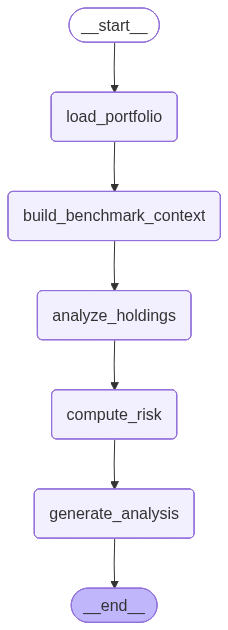

In [39]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("(Graph visualisation requires extra dependencies — skipping)")

## Run the Analytics Pipeline

This will:
1. Load the portfolio from the JSON file
2. Fetch live market data for each holding (~15–30 seconds)
3. Run 17-rule scoring per holding
4. Compute portfolio risk metrics
5. Generate LLM analysis
6. Get structured LLM signals and combine with rules (60/40)

In [40]:
print("=" * 70)
print("RUNNING PORTFOLIO ANALYTICS AGENT")
print("=" * 70)

result = graph.invoke(AnalyticsState())

print("\n" + "=" * 70)
print("Pipeline complete!")
print("=" * 70)

RUNNING PORTFOLIO ANALYTICS AGENT
  [Node 1] Loading portfolio...
    'Sample Balanced Growth Portfolio' with 9 holdings
  [Node 2] Building benchmark context...
    Compared 12 sectors
  [Node 3] Analysing holdings (live data + 17-rule scoring)...
    → VTI (25.0%)... Score: 5 [HOLD]
    → QQQ (15.0%)... Score: 4 [HOLD]
    → XLV (10.0%)... Score: 7 [HOLD]
    → VWO (10.0%)... Score: 8 [HOLD]
    → XLE (5.0%)... Score: 10 [BUY]
    → AAPL (10.0%)... Score: 5 [HOLD]
    → JNJ (5.0%)... Score: 7 [HOLD]
    → BND (15.0%)... Score: 4 [HOLD]
    → GLD (5.0%)... Score: 4 [HOLD]
    9 holdings analysed
  [Node 4] Computing risk metrics...
    Beta: 0.854, P/E: 27.06, Risk: LOW
  [Node 5] Generating LLM analysis...
Loading LLM: openai / gpt-4.1-mini
    Comprehensive analysis generated
    → Getting structured LLM signals...
    Combined signals computed (60% rules / 40% LLM)

Pipeline complete!


/opt/homebrew/lib/python3.11/site-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=HoldingSignals(signals=[H...='GLD', signal='HOLD')]), input_type=HoldingSignals])
  return self.__pydantic_serializer__.to_python(


## View the LLM Analysis

In [41]:
analysis_message = result["messages"][-1]
display(Markdown(analysis_message.content))

# Portfolio Analysis Report

---

## Sector Exposure

- **Overweight Sectors:**
  - Unknown sectors dominate at **85.0%** vs 0% in S&P 500 (likely ETFs with mixed or unclassified sectors).
- **Underweight Sectors:**
  - Technology: 10.0% vs 31.0% (-21.0%)
  - Healthcare: 5.0% vs 12.0% (-7.0%)
  - Financial Services: 0% vs 13.0% (-13.0%)
  - Communication Services: 0% vs 9.0% (-9.0%)
  - Consumer Cyclical: 0% vs 10.0% (-10.0%)
  - Other sectors (Basic Materials, Industrials, Real Estate, Utilities, Energy) also underweight or zero.
- **Concentration Risks:**
  - Heavy concentration in "Unknown" sector (85%) driven by ETFs (VTI, QQQ, VWO, BND, GLD).
  - Single-stock concentration: VTI alone is 25% of portfolio.
  - Technology and Healthcare single-stock exposure limited to AAPL (10%) and JNJ (5%).

---

## Individual Holdings Review

| Ticker | Allocation | RSI  | MACD    | Rule Signal | Total Score | Notes                          |
|--------|------------|------|---------|-------------|-------------|--------------------------------|
| VTI    | 25.0%      | 49.5 | -0.1674 | HOLD        | 5           | Neutral RSI, MACD bearish      |
| QQQ    | 15.0%      | 42.0 | -4.1054 | HOLD        | 4           | RSI low-mid, MACD bearish      |
| XLV    | 10.0%      | 56.8 | 0.3954  | HOLD        | 7           | Positive MACD, healthy score   |
| VWO    | 10.0%      | 67.8 | 0.6628  | HOLD        | 8           | Near overbought, strong score  |
| XLE    | 5.0%       | 67.4 | 1.926   | BUY         | 10          | Strong buy signal, bullish MACD|
| AAPL   | 10.0%      | 54.2 | 0.1425  | HOLD        | 5           | Neutral RSI, weak MACD         |
| JNJ    | 5.0%       | 75.6 | 7.6891  | HOLD        | 7           | Overbought RSI, strong MACD    |
| BND    | 15.0%      | 76.9 | 0.237   | HOLD        | 4           | Overbought RSI, bond ETF       |
| GLD    | 5.0%       | 57.6 | 8.3393  | HOLD        | 4           | Neutral RSI, MACD bearish      |

- **SELL signals:** None flagged.
- **Strong BUY signal:** XLE (Energy ETF) with score 10.
- **Overbought positions (RSI > 70):** JNJ (75.6), BND (76.9).
- **Oversold positions (RSI < 30):** None.

---

## Risk Assessment

- **Portfolio Beta:** 0.854 (below market beta 1.0) indicating lower volatility exposure.
- **Concentration Risk:**
  - Max single holding: VTI at 25%.
  - Sector concentration: 85% in Unknown sector (mostly ETFs), Technology only 10%, Healthcare 5%.
  - Concentration HHI: 0.145 (moderate concentration).
- **Valuation Risk:**
  - Weighted average P/E: 27.06, slightly above typical market average (~20-25), indicating modest valuation premium.
  - Individual P/E extremes: AAPL (33.5), QQQ (32.7), VWO (17.6), XLE (21.9).

---

## ROI & Performance Indicators

- **Strong Momentum Holdings:**
  - XLE: MACD bullish (1.926 > signal 1.8797), RSI 67.4 (near upper momentum range).
  - VWO: MACD slightly bearish (0.6628 < 0.6774), RSI 67.8 (strong momentum).
  - JNJ: Strong MACD bullish, but RSI overbought.
- **Dividend Income Potential:**
  - BND (3.85%), XLE (2.87%), VWO (2.66%), JNJ (2.11%), XLV (1.6%), VTI (1.1%).
  - Portfolio has a moderate dividend yield focus via bond and sector ETFs.
- **Growth vs Value Tilt:**
  - Growth tilt via Technology (AAPL, QQQ) and Emerging Markets (VWO).
  - Value tilt via Energy (XLE), Healthcare (JNJ), and Bonds (BND).
  - Overall balanced but slightly growth-leaning given tech exposure.

---

## Rebalancing Recommendations

1. **Reduce Overweight in Unknown Sector ETFs:**
   - Consider trimming VTI (25%) and QQQ (15%) to reduce concentration and increase sector clarity.
2. **Increase Exposure to Underweight Sectors:**
   - Add Financials, Consumer Cyclical, Communication Services to better align with S&P 500 diversification.
3. **Trim Overbought Positions:**
   - Consider reducing JNJ (5%) and BND (15%) due to RSI > 75 to lock in gains and reduce risk.
4. **Increase Strong Buy Holding:**
   - Consider adding to XLE (currently 5%) to capitalize on strong momentum and dividend yield.
5. **Add Select Individual Stocks or Sector ETFs:**
   - To reduce "Unknown" sector dominance and improve transparency.
6. **Priority Actions:**
   - **High:** Reduce VTI and QQQ allocations to lower concentration risk.
   - **Medium:** Trim JNJ and BND to manage overbought risk.
   - **Medium:** Increase XLE and add Financials/Consumer Cyclical exposure.
   - **Low:** Monitor AAPL and XLV for momentum changes.

---

# Summary

The portfolio is heavily concentrated in broad ETFs classified as "Unknown" sector, leading to underweight exposure in key S&P 500 sectors like Financials and Consumer Cyclical. No holdings currently signal SELL, but some are overbought and may warrant trimming. The portfolio beta is low, indicating moderate risk, with a slight growth tilt. Rebalancing should focus on reducing ETF concentration, increasing sector diversification, and capitalizing on strong momentum in Energy (XLE).

## Inspect: Sector Benchmark

In [42]:
print(result["benchmark_context"])

PORTFOLIO WEIGHT ANALYSIS DATA

Portfolio Holdings:
  VTI (Vanguard Total Stock Market ETF): 25.0% - Sector: Unknown
  QQQ (Invesco QQQ Trust, Series 1): 15.0% - Sector: Unknown
  XLV (State Street Health Care Select): 10.0% - Sector: Unknown
  VWO (Vanguard FTSE Emerging Markets ): 10.0% - Sector: Unknown
  XLE (State Street Energy Select Sect): 5.0% - Sector: Unknown
  AAPL (Apple Inc.): 10.0% - Sector: Technology
  JNJ (Johnson & Johnson): 5.0% - Sector: Healthcare
  BND (Vanguard Total Bond Market ETF): 15.0% - Sector: Unknown
  GLD (SPDR Gold Shares): 5.0% - Sector: Unknown

Sector Allocation Comparison (Portfolio vs S&P 500 Benchmark):
  Basic Materials: Portfolio 0.0% vs S&P 500 2.0% (Difference: -2.0%)
  Communication Services: Portfolio 0.0% vs S&P 500 9.0% (Difference: -9.0%)
  Consumer Cyclical: Portfolio 0.0% vs S&P 500 10.0% (Difference: -10.0%)
  Consumer Defensive: Portfolio 0.0% vs S&P 500 6.0% (Difference: -6.0%)
  Energy: Portfolio 0.0% vs S&P 500 4.0% (Difference: -4

## Inspect: Per-Holding Analysis with Combined Signals

In [43]:
print("=" * 90)
print(f"{'Ticker':<7} {'Alloc':>5} {'Price':>10} {'RSI':>6} {'Score':>6} "
      f"{'Rule':>6} {'LLM':>6} {'Combined':<20}")
print("=" * 90)
for h in result["holdings_analysis"]:
    ticker = h.get("ticker", "?")
    alloc = f"{h.get('allocation_pct', 0):.1f}%"
    price = f"${h['current_price']:.2f}" if h.get('current_price') else 'N/A'
    rsi = f"{h['rsi']:.1f}" if h.get('rsi') else 'N/A'
    score = h.get('total_score', 'N/A')
    rule = h.get('rule_signal', 'N/A')
    llm = h.get('llm_signal', '-')
    combined = h.get('combined_signal', '-')
    print(f"  {ticker:<6} {alloc:>5} {price:>10} {rsi:>6} {score:>6} "
          f"{rule:>6} {llm:>6} {combined:<20}")

Ticker  Alloc      Price    RSI  Score   Rule    LLM Combined            
  VTI    25.0%    $340.27   49.5      5   HOLD   HOLD MAINTAIN / WATCH    
  QQQ    15.0%    $608.81   42.0      4   HOLD   HOLD MAINTAIN / WATCH    
  XLV    10.0%    $156.82   56.8      7   HOLD   HOLD MAINTAIN / WATCH    
  VWO    10.0%     $58.53   67.8      8   HOLD   HOLD MAINTAIN / WATCH    
  XLE     5.0%     $54.88   67.4     10    BUY    BUY KEEP / INCREASE     
  AAPL   10.0%    $264.58   54.2      5   HOLD   HOLD MAINTAIN / WATCH    
  JNJ     5.0%    $242.49   75.6      7   HOLD   HOLD MAINTAIN / WATCH    
  BND    15.0%     $74.81   76.9      4   HOLD   HOLD MAINTAIN / WATCH    
  GLD     5.0%    $468.62   57.6      4   HOLD   HOLD MAINTAIN / WATCH    


## Inspect: Portfolio Risk Metrics

In [44]:
metrics = result["risk_metrics"]
print(f"  Overall Risk Level:     {metrics.get('overall_risk_level', 'N/A')}")
print(f"  Weighted Avg Beta:      {metrics.get('weighted_avg_beta', 'N/A')}")
print(f"  Weighted Avg P/E:       {metrics.get('weighted_avg_pe', 'N/A')}")
print(f"  Concentration HHI:      {metrics.get('concentration_hhi', 'N/A')}")
print(f"  Max Single Holding:     {metrics.get('max_single_holding_pct', 'N/A')}%")
print(f"  High-Risk Holdings:     {metrics.get('high_risk_holdings', [])}")
print(f"  Holdings with data:     {metrics.get('holdings_with_data', 'N/A')}")
print(f"  Holdings without data:  {metrics.get('holdings_without_data', 'N/A')}")
print(f"\n  Sector Breakdown:")
for sector, pct in metrics.get('sector_breakdown', {}).items():
    print(f"    {sector:<25} {pct:>5.1f}%")

  Overall Risk Level:     LOW
  Weighted Avg Beta:      0.854
  Weighted Avg P/E:       27.06
  Concentration HHI:      0.145
  Max Single Holding:     25.0%
  High-Risk Holdings:     []
  Holdings with data:     9
  Holdings without data:  0

  Sector Breakdown:
    Unknown                    85.0%
    Technology                 10.0%
    Healthcare                  5.0%


## Inspect: Detailed Rule Scores (Per Holding)

See all 17 individual rule scores for each holding.

In [45]:
for h in result["holdings_analysis"]:
    if h.get("rule_scores"):
        print(f"\n{'=' * 50}")
        print(f"{h['ticker']} - Rule Score Breakdown")
        print(f"{'=' * 50}")
        for rule, value in h["rule_scores"].items():
            if rule != "total_score":
                indicator = "" if value > 0 else "" if value < 0 else ""
                print(f"  {indicator} {rule:<20} {value:>+3}")
        print(f"  {'':>22} ----")
        print(f"  {'TOTAL':<22} {h['rule_scores']['total_score']:>+3}  → {h.get('rule_signal', '?')}")

## Demo: Portfolio Analytics Queries

Now that the pipeline has run and we have the full analysis, we can
ask the LLM specific questions about the portfolio. The `ask()` function
sends each question along with the analysis context so the LLM can
give informed, data-backed answers.

In [46]:
def ask(question: str) -> str:
    """Ask a question about the portfolio using the analysis results as context."""
    # Build context from the pipeline results
    context_parts = []
    context_parts.append("PORTFOLIO ANALYSIS RESULTS\n")
    context_parts.append(result["benchmark_context"])
    context_parts.append("\nPER-HOLDING ANALYSIS:")
    context_parts.append(json.dumps(
        [
            {k: v for k, v in h.items() if k != "rule_scores"}
            for h in result["holdings_analysis"]
        ],
        indent=2, default=str,
    ))
    context_parts.append("\nPORTFOLIO RISK METRICS:")
    context_parts.append(json.dumps(result["risk_metrics"], indent=2, default=str))
    context_parts.append("\nLLM ANALYSIS REPORT:")
    context_parts.append(result["messages"][-1].content)

    llm = load_llm_from_env()
    messages = [
        SystemMessage(content=(
            "You are an expert investment analyst. You have been provided with "
            "a complete portfolio analysis including sector benchmarks, per-holding "
            "technical/fundamental data, risk metrics, and a prior analysis report. "
            "Answer the user's question using this data. Be specific — cite ticker "
            "symbols, percentages, and scores. Keep your answer concise and actionable."
        )),
        HumanMessage(content=f"CONTEXT:\n{chr(10).join(context_parts)}\n\nQUESTION: {question}"),
    ]
    return llm.invoke(messages).content


print("ask() helper ready")
print("\nUsage: ask('your question about the portfolio')")

ask() helper ready

Usage: ask('your question about the portfolio')


In [47]:
# Demo 1: Overall portfolio health
print("=" * 70)
print("Demo 1: Portfolio Health Check")
print("=" * 70)

print("\nUser: Here are my holdings — how is my portfolio doing?")
response = ask("Here are my holdings — how is my portfolio doing?")
print(f"\nBot: {response}")

Demo 1: Portfolio Health Check

User: Here are my holdings — how is my portfolio doing?
Loading LLM: openai / gpt-4.1-mini

Bot: Your portfolio is currently well-diversified across broad ETFs but shows significant concentration and sector imbalances:

- **Concentration & Sector Exposure:**
  - Heavy concentration in "Unknown" sector ETFs (85%), mainly VTI (25%), QQQ (15%), VWO (10%), BND (15%), and GLD (5%).
  - Underweight in key S&P 500 sectors: Financials (0% vs 13%), Consumer Cyclical (0% vs 10%), Communication Services (0% vs 9%), and Technology (10% vs 31%).
  - Single-stock exposure limited to AAPL (10%) and JNJ (5%) in Technology and Healthcare.

- **Performance & Signals:**
  - No SELL signals; most holdings are HOLD with neutral momentum.
  - Strong BUY signal on XLE (Energy ETF, 5%) with bullish MACD and RSI near 67, suggesting opportunity to increase.
  - Overbought RSI on JNJ (75.6) and BND (76.9) suggests trimming these to lock gains and reduce risk.

- **Risk & Valuation

In [48]:
# Demo 2: ROI analysis
print("=" * 70)
print("Demo 2: Total ROI")
print("=" * 70)

print("\nUser: What is my total ROI?")
response = ask("What is my total ROI?")
print(f"\nBot: {response}")

Demo 2: Total ROI

User: What is my total ROI?
Loading LLM: openai / gpt-4.1-mini

Bot: The provided data does not include explicit total ROI or historical performance figures for the portfolio or individual holdings. The analysis focuses on current technical/fundamental metrics, sector allocation, risk, and signals but does not report realized or projected returns.

To estimate total ROI, you would need historical price data or portfolio performance tracking over a specific period, which is not available here.

Actionable next step: Track portfolio value changes over time or use a portfolio management tool to calculate total ROI based on purchase prices and current valuations.


In [49]:
# Demo 3: Sector concentration
print("=" * 70)
print("Demo 3: Healthcare Concentration")
print("=" * 70)

print("\nUser: Am I too concentrated in healthcare?")
response = ask("Am I too concentrated in healthcare?")
print(f"\nBot: {response}")

Demo 3: Healthcare Concentration

User: Am I too concentrated in healthcare?
Loading LLM: openai / gpt-4.1-mini

Bot: No, your portfolio is not too concentrated in healthcare. Healthcare exposure is only 5% (JNJ), which is significantly underweight compared to the S&P 500 benchmark's 12% allocation—a difference of -7%. Your largest healthcare holding is JNJ at 5%, with a HOLD signal and no SELL alerts. The portfolio's main concentration risk lies in the "Unknown" sector ETFs (85%), not healthcare.


In [50]:
# Demo 4: Volatility assessment
print("=" * 70)
print("Demo 4: Portfolio Volatility")
print("=" * 70)

print("\nUser: How volatile is my portfolio?")
response = ask("How volatile is my portfolio?")
print(f"\nBot: {response}")

Demo 4: Portfolio Volatility

User: How volatile is my portfolio?
Loading LLM: openai / gpt-4.1-mini

Bot: Your portfolio has a **low overall volatility** profile, supported by these key metrics:

- **Weighted average beta:** 0.854, which is below the market beta of 1.0, indicating your portfolio is less volatile than the overall market.
- **No high-risk holdings** identified.
- **Moderate concentration risk** with a concentration HHI of 0.145 and max single holding at 25% (VTI).
- Sector exposure is heavily weighted (85%) in broad ETFs classified as "Unknown," which typically have diversified holdings that reduce volatility.
- Individual stocks like AAPL and JNJ have moderate betas (AAPL 1.107, JNJ 0.347), balancing growth and defensive characteristics.

**Actionable insight:** Your portfolio's low beta and diversified ETF exposure suggest moderate risk and volatility. To maintain or further reduce volatility, consider trimming concentrated ETF positions (VTI, QQQ) and increasing expo

In [51]:
# Demo 5: Benchmark comparison
print("=" * 70)
print("Demo 5: S&P 500 Comparison")
print("=" * 70)

print("\nUser: Compare my returns to S&P 500.")
response = ask("Compare my returns to S&P 500.")
print(f"\nBot: {response}")

Demo 5: S&P 500 Comparison

User: Compare my returns to S&P 500.
Loading LLM: openai / gpt-4.1-mini

Bot: Your portfolio's sector allocation is significantly different from the S&P 500 benchmark, which will impact relative returns:

- Heavy concentration (85%) in broad ETFs (VTI, QQQ, VWO, BND, GLD) classified as "Unknown" sector, versus 0% in S&P 500.
- Underweight in key S&P 500 sectors: Technology (10% vs 31%), Healthcare (5% vs 12%), Financials (0% vs 13%), Consumer Cyclical (0% vs 10%), Communication Services (0% vs 9%).
- Your portfolio has a lower beta (0.854) than the market (1.0), indicating lower volatility and likely lower upside capture in strong bull markets.
- Weighted average P/E of 27.06 is slightly above typical market average, suggesting modest valuation premium.
- Strong momentum in Energy (XLE) and Emerging Markets (VWO) may provide some outperformance in those sectors.
- Overbought positions (JNJ, BND) may face short-term pullbacks, while no holdings signal SELL.



In [52]:
# Demo 6: Rebalancing advice
print("=" * 70)
print("Demo 6: Rebalancing")
print("=" * 70)

print("\nUser: Should I rebalance?")
response = ask("Should I rebalance?")
print(f"\nBot: {response}")

Demo 6: Rebalancing

User: Should I rebalance?
Loading LLM: openai / gpt-4.1-mini

Bot: Yes, rebalancing is advisable to reduce concentration risk and improve sector diversification:

- **Reduce VTI (25%) and QQQ (15%) allocations** to lower the heavy 85% "Unknown" sector concentration and single-stock concentration in VTI.
- **Trim JNJ (5%) and BND (15%)** due to overbought RSI (>75) to lock in gains and reduce risk.
- **Increase XLE (5%)** exposure, which has a strong BUY signal, bullish momentum, and attractive dividend yield.
- **Add exposure to underweight sectors** like Financial Services, Consumer Cyclical, and Communication Services to better align with S&P 500 sector weights.
- **Monitor AAPL (10%) and XLV (10%)** for momentum changes but maintain current positions for now.

This rebalancing will lower concentration risk (currently HHI 0.145), improve diversification, and capitalize on strong momentum in Energy.


In [53]:
# Demo 7: Underperforming ETF identification
print("=" * 70)
print("Demo 7: Underperforming ETFs")
print("=" * 70)

print("\nUser: Which ETF is underperforming?")
response = ask("Which ETF is underperforming?")
print(f"\nBot: {response}")

Demo 7: Underperforming ETFs

User: Which ETF is underperforming?
Loading LLM: openai / gpt-4.1-mini

Bot: The ETF QQQ is underperforming relative to others in the portfolio. It has a low RSI of 42.0 (indicating weak momentum), a bearish MACD (-4.1054 below signal line -3.3736), a total score of 4, and a "HOLD" combined signal. In contrast, XLE shows a strong buy signal with a total score of 10 and bullish momentum indicators. VTI and other ETFs have neutral to positive signals but QQQ stands out as the weakest performer technically.


## Summary

- Reads portfolio from Notebook 11 output (JSON file)
- 17 rule-based scoring rules (MACD, RSI, SMA, P/E, P/B, ROE, dividends, 52-week range)
- Structured LLM signals via `with_structured_output` (Pydantic `HoldingSignals`)
- Combined recommendations: 60% rule-based + 40% LLM-based
- Portfolio risk metrics: HHI, beta, P/E, sector breakdown, high-risk detection
- LLM comprehensive analysis: sector exposure, ROI, risk, rebalancing

### Two-Agent System
```
Notebook 11 (Builder)  ->  portfolio.json  ->  Notebook 12 (Analytics Agent)
```

### Architecture
```
load_portfolio -> build_benchmark_context -> analyze_holdings
    -> compute_risk -> generate_analysis -> END
```